In [1]:
import numpy as np
import pandas as pd
import os, os.path
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import scipy.stats
import pickle
from statsmodels.distributions.empirical_distribution import ECDF
import pybobyqa
from tqdm import tqdm

In [2]:

def upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper):
    cap_static = np.load(os.path.join(ROOT_DIR,f'{save_folder}/{city}/PHI_{phi}/ETA_{eta}/Th_{delay}/cap_fore_uncer_test_block1_delay_{delay}_phi_{phi}_gamma_2_deltax_005.npy'))
    cap_shared=np.load(os.path.join(ROOT_DIR,f'{save_folder}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy'))
    #cap_shared = np.load(f'Results/{city}/Th_{delay}/shared_fore_uncer_block2_delay_{delay}_phi_{phi}_alpha_{alpha}_gamma_2.npy')
    cap_static = cap_static.clip(min=0)
    cap_shared = cap_shared.clip(min=0)
    print ( f'cap_shared.shape {cap_shared.shape} (Block 2) ,\n cap_static.shape {cap_static.shape} (Block 1)')
    dist_cd = scipy.stats.norm(loc=cap_static.mean(axis=-1),
                               scale=cap_static.std(axis=-1))
    dist_cs = scipy.stats.norm(loc=cap_shared.mean(axis=-1),
                               scale=cap_shared.std(axis=-1))
    
    ppf_static = 0.999
    ppf_helper = 0.999

    upper_cd_static = dist_cd.ppf(ppf_static) # Can be changed. If set to 0.5 = mean
    upper_cd_static[np.where(np.isnan(upper_cd_static))] = (
        cap_static[np.where(np.isnan(upper_cd_static))][:, 0])
    upper_cs_shared = dist_cs.ppf(ppf_helper) # Can be changed. If set to 0.5 = mean 
    upper_cs_shared[np.where(np.isnan(upper_cs_shared))] = (
        cap_shared[np.where(np.isnan(upper_cs_shared))][:, 0])

    return upper_cd_static, upper_cs_shared

def cost_func_evaluation(c_plus, forecasting, static, phi, alpha):
    ''' Evaluate the cost of the allocation given cplus selected.'''
    # cost_shared = phi
    cost_sla = alpha
    total_cost = 0
    for i in range(forecasting.shape[0]):  # shape[0] = num services
        # total_cost += cost_shared * c_plus[i]
        ecdf = ECDF(forecasting[i])
        total_cost += (1-ecdf(static[i] + c_plus[i])) * cost_sla
    return total_cost

def apps_need_shared(forecasting, static):
    ''' Return the slices that need shared capacity '''
    index_app = []
    for app in range(forecasting.shape[0]):
        dist = ECDF(forecasting[app])
        if (1 - dist(static[app])) != 0:
            index_app.append(app)
    return index_app


def fun(pn, dist, static, max_shared, phi, alpha, lower_bound, upper_bound,obj_noise_test): # Golden search
    """ Function with only one variable to be minimized through
        bounded golden search
    """
    num_app = dist.shape[0]
    p_0 = np.ones(num_app) * 0.5
    opt = pybobyqa.solve(cost_func_evaluation_p_fix_p4, p_0,
                         bounds=(lower_bound[:num_app], upper_bound[:num_app]),
                         args=(dist, static, max_shared, pn, phi, alpha),
                         objfun_has_noise=obj_noise_test)
    return opt.f


def cost_func_evaluation_p(p, forecasting, static, shared_available, phi,
                           alpha):
    ''' Evaluate the cost of the allocation given cplus selected.'''
    # cost_shared = phi
    cost_sla = alpha
    total_cost = 0
    cplus = return_cplus(p, shared_available)
    for i in range(forecasting.shape[0]):  # shape[0] = num services
        # total_cost += cost_shared * cplus[i]
        ecdf = ECDF(forecasting[i])
        # print (f'ECDF : {ecdf(static[i] + cplus[i])}')
        total_cost += (1-ecdf(static[i] + cplus[i])) * cost_sla
    return total_cost


def cost_func_evaluation_p_fix_p4(p, forecasting, static, shared_available, p4,
                                  phi, alpha):
    ''' Evaluate the cost of the allocation given cplus selected.'''
    # cost_shared = phi
    cost_sla = alpha
    total_cost = 0
    cplus, cplus_4 = return_cplus_fix_p4(p, shared_available, p4)
    for i in range(forecasting.shape[0]):  # shape[0] = num services
        # total_cost += cplus[i] * phi
        ecdf = ECDF(forecasting[i])
        # print (f'ECDF : {ecdf(static[i] + cplus[i])}')
        total_cost += (1-ecdf(static[i] + cplus[i])) * cost_sla
    return total_cost


def return_cplus(p_vector, shared_available): # Transform function from the paper
    """ Return c_plus given p and max amount of shared for
    that phi,alpha and time.
    """
    cplus = np.zeros(p_vector.shape)
    products = np.zeros(p_vector.shape[0]-1)
    for i in range(len(cplus)-1):
        products[i] = np.true_divide(np.prod(p_vector[i:-1]),
                                     np.prod((1-p_vector)[i:-1]))
    cplus[-1] = np.true_divide(shared_available * p_vector[-1],
                               np.sum(products) + 1)[0]
   
    for i in range(len(cplus)-1):
        cplus[i] = products[i] * cplus[-1]
    return cplus


def return_cplus_fix_p4(p_vector, shared_available, p4): # Transform function from the paper
    """ Return c_plus given p and max amount of shared for
    that phi,alpha and time. """
    cplus = np.zeros(p_vector.shape)
    products = np.zeros(p_vector.shape[0])
    for i in range(len(cplus)):
        products[i] = np.true_divide(np.prod(p_vector[i:]),
                                     np.prod((1-p_vector)[i:]))
    cplus4 = np.true_divide(shared_available * p4,
                            np.sum(products) + 1)
    # for i in range(len(cplus)):
    #     cplus[i] = products[i] * cplus4

    cplus = products * cplus4
    return cplus, cplus4


def return_p(cplus, max_shared):
    p = np.zeros(cplus.shape)
    for i in range(cplus.shape[0] - 1):
        p[i] = cplus[i] / (cplus[i]+cplus[i+1])
    p[-1] = np.sum(cplus) / max_shared
    return p



def load_real_data(city):
    ''' Load the real data for the city.'''

    bordeaux = pd.read_csv(os.path.join(ROOT_DIR,f'./citys/{city}.csv'))
    #bordeaux = pd.read_csv(f'/home/sergi_alcala/AZTEC_extension/citys/{city}.csv')

    bordeaux.drop('date_time', axis=1, inplace=True)
    bordeaux = bordeaux.reindex(sorted(bordeaux.columns), axis=1)
    bordeaux = bordeaux.to_numpy()
    return bordeaux

def load_mae_forecasting(city):
    mae_forecasting = np.transpose(np.load(os.path.join(ROOT_DIR,f'./{save_folder}/{city}/helper_forecasting_delay_1.npy')), (0,2,1))
    
    return mae_forecasting

def load_scalers(city,save_folder, ppf_static, ppf_helper):
    static_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{save_folder}/{city}/PHI_{phi}/ETA_{eta}/Th_{delay}/block_1_minmaxscaler.pkl'), 'rb'))
    shared_scaler = pickle.load(open(os.path.join(ROOT_DIR,f'{save_folder}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}/block_2_minmaxscaler.pkl'), 'rb'))
    return static_scaler, shared_scaler


In [3]:
def montecarlo_stuff(static_val,ppf_val=0.7):
    static_val = static_val.clip(min=0)
                    
            # # Save results of the test model with validation dataset 
            


    dist_load_forecasted = scipy.stats.norm(loc=static_val.mean(axis=-1),
                                        scale=static_val.std(axis=-1))


    # upper_load_forecasted = dist_load_forecasted.ppf(0.7) 
    upper_load_forecasted = dist_load_forecasted.ppf(ppf_val) 

    upper_load_forecasted[np.where(np.isnan(upper_load_forecasted))] = (
    static_val[np.where(np.isnan(upper_load_forecasted))][:, 0])
    return upper_load_forecasted

In [4]:

def denormalize_normalize_static_shared(static,shared, static_scaler,shared_scaler, mae_forecasting, real_data, test_index_start):
    ''' Denormalize the static data using the scaler. '''
    static_denorm = static_scaler.inverse_transform(static) # Static = block 1
    shared_denorm = shared_scaler.inverse_transform(np.expand_dims(shared, axis=-1)) # Shared = block 2
    mae_denorm = np.zeros(mae_forecasting.shape) # MAE = helper
    for i in range(B):
        mae_denorm[:,:,i] = static_scaler.inverse_transform(mae_forecasting[:,:,i])
    ''' Normalize the data to be in the same scale as the real data.'''
    shared_norm = shared_denorm / 10e9 # Shared = block 2
    static_norm = static_denorm / 10e9 # Static = block 1
    mae_norm = mae_denorm / 10e9 # MAE = helper
    output_norm = real_data[test_index_start:] / 10e9 # Real test data

    diff = min(mae_norm.shape[0], output_norm.shape[0], shared_norm.shape[0], static_norm.shape[0])

    mae_norm_diff = mae_norm.shape[0] - diff
    output_norm_diff = output_norm.shape[0] - diff
    shared_norm_diff = shared_norm.shape[0] - diff
    static_norm_diff = static_norm.shape[0] - diff
    print (f'static_norm.shape: {static_norm.shape} \n shared_norm.shape: {shared_norm.shape} \n mae_norm.shape: {mae_norm.shape} \n output_norm.shape: {output_norm.shape}')

    
    if mae_norm_diff != 0:
        mae_norm = mae_norm[mae_norm_diff:]
    if output_norm_diff != 0:
        output_norm = output_norm[output_norm_diff:]
    if shared_norm_diff != 0:
        shared_norm = shared_norm[shared_norm_diff:]
    if static_norm_diff != 0:
        static_norm = static_norm[static_norm_diff:]

 

    
    print (f'static_norm.shape: {static_norm.shape} \n shared_norm.shape: {shared_norm.shape} \n mae_norm.shape: {mae_norm.shape} \n output_norm.shape: {output_norm.shape}')

    return static_norm, shared_norm, mae_norm, output_norm

In [5]:


def create_df_shared_cplus_sla(slas, cplus, shared_needed,num_services,Filesave,delay,phi,alpha):
    
    shared_needed_df=pd.DataFrame(shared_needed)
    cplus_df=pd.DataFrame(cplus)
    slas_df=pd.DataFrame(slas)
    shared_cplus_sla=pd.concat([shared_needed_df, cplus_df, slas_df], axis=0)
    shared_needed_idx=[f'shared_needed_{i}' for i in range(num_services)]
    cplus_idx=[f'cplus_{i}' for i in range(num_services)]
    slas_idx=[f'slas_{i}' for i in range(num_services)]
    shared_cplus_sla.index=shared_needed_idx+cplus_idx+slas_idx
    shared_cplus_sla=shared_cplus_sla.T
    shared_needed_df=shared_needed_df.T
    cplus_df=cplus_df.T
    slas_df=slas_df.T
    shared_cplus_sla.to_csv(os.path.join(ROOT_DIR,f'{Filesave}/Block_3_shared_cplus_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_2.csv'),index=False)
    shared_needed_df.to_csv(os.path.join(ROOT_DIR,f'{Filesave}/Block_3_shared_needed_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_2.csv'),index=False)
    cplus_df.to_csv(os.path.join(ROOT_DIR,f'{Filesave}/Block_3_cplus_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_2.csv'),index=False)
    slas_df.to_csv(os.path.join(ROOT_DIR,f'{Filesave}/Block_3_sla_delay_{delay}_phi_{phi}_alpha{alpha}_gamma_2.csv'),index=False)


    

    return shared_cplus_sla



def allocation_loop(static_norm, shared_norm, mae_norm, output_norm, num_services,  phi, alpha, Filesave):

    

    length_tsteps = min(len(shared_norm),len(output_norm))
    slas = np.zeros((num_services, length_tsteps)) # number of slas for each time step
    cplus = np.zeros((num_services, length_tsteps)) # shared allocated to each app for each time step
    shared_needed=np.zeros((num_services, length_tsteps)) # shared needed for each app for each time step ### Sergi ###
    p = np.zeros((num_services, length_tsteps)) 
    lower_bound = np.ones(num_services) * 1e-10
    upper_bound = np.ones(num_services) * 0.99999
    idx_time = 1
    # for time in [3]:
    for time in tqdm(range(0, length_tsteps)):
        print (f' Time {time} of {length_tsteps} \n')
        forecasting = mae_norm[time] # forecasting.shape = (5, 100)
        idx_app = apps_need_shared(forecasting, static_norm[time])

       


        if len(idx_app) > 1:
        ##Try catch used because the assymetry  of the matrix, solved by changing the parameter objfun_has_noise True or False

            # try:
            obj_noise_test = True
        # Golden search for setting p4
            test = scipy.optimize.minimize_scalar(fun, bounds=(1e-10, 0.99999), method='bounded',
                                                args=(forecasting[idx_app[:-1]], static_norm[time, idx_app[:-1]],
                                                        shared_norm[time], phi, alpha, lower_bound, upper_bound,obj_noise_test))
            # except:
            #     print (f'obj_noise_test = False for time {time}')
            #     obj_noise_test = False
            #     test = scipy.optimize.minimize_scalar(fun, bounds=(1e-10, 0.99999), method='bounded',
            #                                         args=(forecasting[idx_app[:-1]], static_norm[time, idx_app[:-1]],
            #                                                 shared_norm[time], phi, alpha, lower_bound, upper_bound,obj_noise_test))
            p4 = test.x # p4 obtained using golden search
            p_0 = np.ones(len(idx_app)-1) * 0.5 # initial values of p from 0 to 3
            p_0[-1] = p4
        # Finding the best initial values of p from 0 to 3 keeping p4 fixed. BOBYQA for p from 0 to 3.
            # try:
            
            prova = pybobyqa.solve(cost_func_evaluation_p_fix_p4, p_0, bounds=(lower_bound[:len(idx_app)-1],
                                                                            upper_bound[:len(idx_app)-1]),
                                args=(forecasting[idx_app[:-1]], static_norm[time, idx_app[:-1]],
                                        shared_norm[time], p4, phi, alpha), objfun_has_noise=True)
                #print('objfun_has_noise=True for prova')
            # except:
            #     print (f'objfun_has_noise=False for time {time} in prova')
                
            #     prova = pybobyqa.solve(cost_func_evaluation_p_fix_p4, p_0, bounds=(lower_bound[:len(idx_app)-1],
            #                                                                 upper_bound[:len(idx_app)-1]),
            #                     args=(forecasting[idx_app[:-1]], static_norm[time, idx_app[:-1]],
            #                             shared_norm[time], p4, phi, alpha), objfun_has_noise=False)
                #print('objfun_has_noise=False for prova')
            p_0 = np.zeros(len(idx_app))
            p_0[:len(idx_app)-1] = prova.x
            p_0[-1] = p4
        # Now we have the "best" initial values for p, so we run the allocation algorithm for all p. BOBYQA for all p.
            # try:
                
            prova_2 = pybobyqa.solve(cost_func_evaluation_p, p_0, bounds=(lower_bound[:len(idx_app)],
                                                                        upper_bound[:len(idx_app)]),
                                    args=(forecasting[idx_app], static_norm[time, idx_app],
                                        shared_norm[time], phi, alpha), objfun_has_noise=True)
                #print('objfun_has_noise=True for prova_2')
            # except:
            #     print (f'objfun_has_noise=False for time {time} in prova_2')
                
            #     prova_2 = pybobyqa.solve(cost_func_evaluation_p, p_0, bounds=(lower_bound[:len(idx_app)],
            #                                                             upper_bound[:len(idx_app)]),
            #                         args=(forecasting[idx_app], static_norm[time, idx_app],
            #                             shared_norm[time], phi, alpha), objfun_has_noise=False)
            #print('objfun_has_noise=False for prova_2')
            cplus[idx_app, time] = return_cplus(prova_2.x, shared_norm[time]) # cplus = shared capacity allocated to each service.
            p[idx_app, time] = prova_2.x
        elif len(idx_app) == 1:
        # In case we have only one application requesting shared capacity, I assign all the shared available to it.
            cplus[idx_app, time] = shared_norm[time]
        shared_needed[:, time] = output_norm[time] - static_norm[time]
        forecasting_mt = montecarlo_stuff(forecasting,0.999)
        shared_predicted = forecasting_mt - static_norm[time] # It gives you the total shared required at that time.
        for app in range(num_services):
            if shared_needed[app, time] > cplus[app, time]:
                slas[app, time] += 1

        
        print(f'\rTime={time}, {idx_app}, \n Shared needed: {shared_needed[:,time]},  \nshared_predicted : {shared_predicted} \n cplus: {cplus[:, time]}, \n mae : {forecasting_mt} \n slas: {slas[:, time]}, ', end='')
    # create_df_shared_cplus_sla(slas, cplus, shared_needed,num_services,Filesave,delay,phi,alpha) ### Sergi ###
    print('Optimization done')

    return slas,cplus,shared_needed


In [6]:

import sys


# ROOT_DIR = os.path.realpath(os.path.join(os.path.dirname(__file__), '.'))
ROOT_DIR='/home/sergi_alcala/sergi_data/AZTEC_extension'
print(f'Root dir: {ROOT_DIR}')

lookback = 6
num_services = 5

B = 100
# test_index_start = 2016*8 + delay   # First sample start at test + 6.

def fun_test_index_start(city,delay):
    bordeaux= load_real_data(city)
    test_index_start = round(len(bordeaux)*0.8) + delay
    return test_index_start





LOOKBACK = 6 # History given as input to the network. Could be modified if needed

GAMMA = 2 # Positive slope of the loss function
NUM_SERV_B1 = 5 # number of services for the block 1
NUM_SERV_H = 1 # number of services for the helper

#B = 100 # Number of montecarlo output
B=100
#ppf_helper = 0.75 # Percentile of the helper
#ppf_static = 0.1 # Percentile of the static model


# ppf_helper_list=[0.5,0.65,0.70,0.75,0.9,0.95,0.99]
# ppf_helper_list=[0.99]
ppf_helper_list=[0.7]
# ppf_static_list=[0.2,0.3,0.5,0.75,0.9]
ppf_static_list=[0.9]

SEL_SERVS=[0, 1, 2, 3, 4] #Services to be selected for Helper Block
# PHIS = [10,1,0.1] # Negative slope of the loss function TO BE MODIFIED 
PHIS=[0.1]
# cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
#         'Nice', 'Paris', 'Reims', 'Rennes', 'Strasbourg', 'Toulouse']
# cities = ['Bordeaux','Dijon', 'Grenoble', 'Lille', 'Lyon', 'Marseille', 'Montpellier', 'Nantes',
        # 'Nice', 'Paris', 'Reims', 'Rennes']
cities = ['Paris']

#Error in city Toulouse, phi 10, alpha 3, delay 6, ppf_static 0.9, ppf_helper 0.99

#save_folder = 'Results_Pipeline'   
# save_folder = 'Test_lengths'
TB_Fpath = 'TEST_4_H'
save_folder = 'Results_Optimal_Cities_test_kr_ki_ALLOC_changed_b2'




Root dir: /home/sergi_alcala/sergi_data/AZTEC_extension


In [7]:


# ALPHAS=[0.75,2,3,5]
# ALPHAS=[2,3,5]
ALPHAS = [2]
ETAS = [100]
for city in tqdm(cities):
    for ppf_helper in tqdm(ppf_helper_list):
        for ppf_static in tqdm(ppf_static_list):
            for phi in tqdm(PHIS):  
                for alpha in tqdm(ALPHAS):
                    for eta in tqdm(ETAS):
                        delay=np.load(f'{ROOT_DIR}/{save_folder}/{city}/PHI_{phi}/ETA_{eta}/overall_optimal_window.npy')
                        # delay=5
                        Filesave=f'{save_folder}/{city}/PHI_{phi}/ETA_{eta}/Block_2_3_results/ppf_static_{ppf_static}_ppf_helper_{ppf_helper}/Th_{delay}'
                        test_index_start=fun_test_index_start(city,delay)
                        print(f'City: {city}, ppf_static: {ppf_static}, ppf_helper: {ppf_helper}, phi: {phi}, alpha: {alpha}, delay: {delay}')
                        static_scaler, shared_scaler = load_scalers(city,save_folder, ppf_static, ppf_helper)
                        real_data, mae_forecasting=load_real_data(city),load_mae_forecasting(city)
                        static,shared=upload_static_shared(phi, alpha, delay, num_services, B, city,ppf_static,ppf_helper)
                        static_norm, shared_norm, mae_norm, output_norm = denormalize_normalize_static_shared(static, shared, static_scaler, shared_scaler, mae_forecasting, real_data, test_index_start)
                        


  0%|          | 0/1 [00:00<?, ?it/s]











City: Paris, ppf_static: 0.9, ppf_helper: 0.7, phi: 0.1, alpha: 2, delay: 85


/home/sergi_alcala/anaconda3/envs/AZTEC_ext/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2244: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/sergi_alcala/anaconda3/envs/AZTEC_ext/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2245: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc




100%|██████████| 1/1 [00:00<00:00,  5.39it/s]



100%|██████████| 1/1 [00:00<00:00,  5.24it/s]


100%|██████████| 1/1 [00:00<00:00,  5.09it/s]

100%|██████████| 1/1 [00:00<00:00,  4.74it/s]


cap_shared.shape (3570, 100) (Block 2) ,
 cap_static.shape (3570, 5, 100) (Block 1)
static_norm.shape: (3570, 5) 
 shared_norm.shape: (3570, 1) 
 mae_norm.shape: (3576, 5, 100) 
 output_norm.shape: (3497, 5)
static_norm.shape: (3497, 5) 
 shared_norm.shape: (3497, 1) 
 mae_norm.shape: (3497, 5, 100) 
 output_norm.shape: (3497, 5)


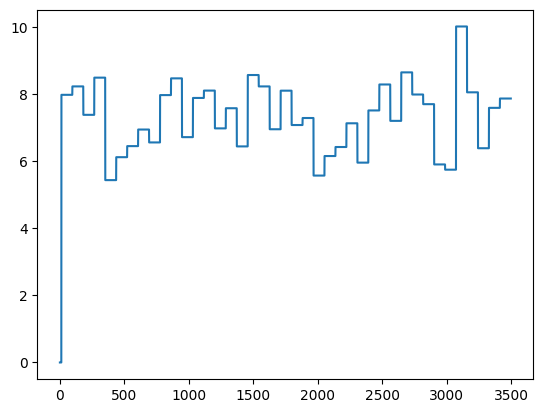

In [22]:
plt.plot(shared_norm)

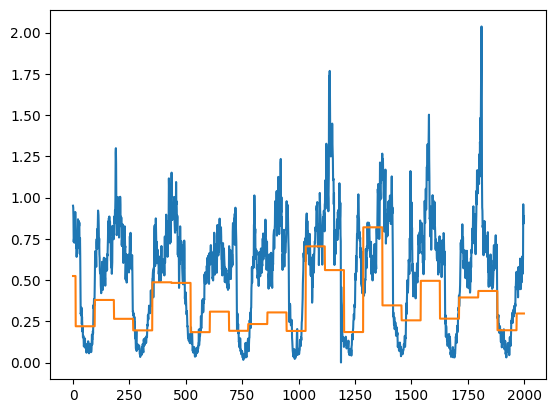

In [23]:
start = 0
end = 2000
plt.plot(output_norm[start:end,0])
plt.plot(static_norm[start:end,0])

In [8]:
static_norm, shared_norm, mae_norm, output_norm =static_norm [12:] , shared_norm[12:] , mae_norm [12:], output_norm [12:]

In [9]:
test_len = 60

static_norm, shared_norm, mae_norm, output_norm = static_norm [:test_len], shared_norm[:test_len], mae_norm [:test_len], output_norm [ :test_len]

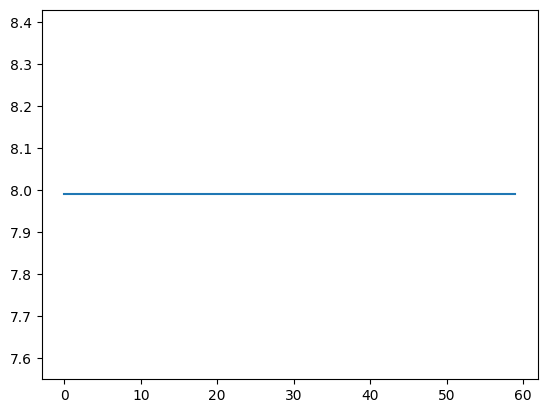

In [10]:
plt.plot(shared_norm)

In [37]:
static_norm_sum= static_norm.sum(axis=1)
shared_norm_sum= shared_norm.sum(axis=1)
cplus_sum = cplus.sum(axis=0)
output_norm_sum = output_norm.sum(axis=1)

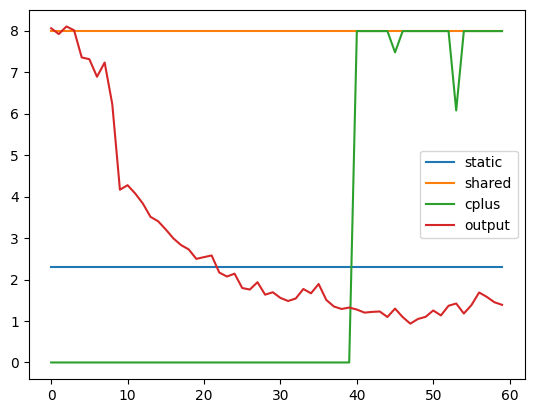

In [27]:
plt.plot(static_norm_sum,label='static')
plt.plot(shared_norm_sum,label='shared')
plt.plot(cplus_sum,label=  'cplus')
plt.plot(output_norm_sum,label='output')
plt.legend()

In [11]:
slas,cplus,shared_needed = allocation_loop(static_norm, shared_norm, mae_norm, output_norm, num_services,  phi, alpha,Filesave)

  0%|          | 0/60 [00:00<?, ?it/s]

 Time 0 of 60 



  2%|▏         | 1/60 [00:45<45:03, 45.82s/it]

Time=0, [0, 1, 2, 3, 4], 
 Shared needed: [0.58153394 0.69772062 1.30791589 2.81519727 0.51245252],  
shared_predicted : [0.84515597 0.93457234 1.37243072 3.16115128 0.53866572] 
 cplus: [1.0148463  3.01197587 1.42001706 0.19222354 0.13943365], 
 mae : [1.06495195 1.22916701 1.93121587 4.03065223 0.90315037] 
 slas: [0. 0. 0. 1. 1.],  Time 1 of 60 



/home/sergi_alcala/anaconda3/envs/AZTEC_ext/lib/python3.10/site-packages/pybobyqa/model.py:252: LinAlgWarning: Diagonal number 13 is exactly zero. Singular matrix.
  self.lu, self.piv = LA.lu_factor(A)
/home/sergi_alcala/anaconda3/envs/AZTEC_ext/lib/python3.10/site-packages/pybobyqa/trust_region.py:79: RuntimeWarning: Trust-region solver: fixing non-symmetric Hessian
  warnings.warn("Trust-region solver: fixing non-symmetric Hessian", RuntimeWarning)
  3%|▎         | 2/60 [01:42<50:16, 52.00s/it]

...

Time=57, [0, 1, 2, 3, 4], 
 Shared needed: [-0.11200002 -0.22248231  0.04656872 -0.430184   -0.2902056 ],  
shared_predicted : [ 0.01510895  0.03508874  0.31475078  0.12170026 -0.05399624] 
 cplus: [0.12456487 0.72876692 1.4954358  2.79496875 0.8239804 ], 
 mae : [0.23490493 0.32968341 0.87353593 0.99120122 0.31048841] 
 slas: [0. 0. 0. 0. 0.],  Time 58 of 60 



 98%|█████████▊| 59/60 [21:29<00:02,  2.92s/it]

Time=58, [0, 2, 3], 
 Shared needed: [-0.15597558 -0.20546125 -0.06187621 -0.49484941 -0.29509909],  
shared_predicted : [-0.00113058  0.01770565  0.3216877   0.24104825 -0.03763344] 
 cplus: [1.9858169  0.         4.04360541 1.46218006 0.        ], 
 mae : [0.2186654  0.31230032 0.88047286 1.1105492  0.32685121] 
 slas: [0. 0. 0. 0. 0.],  Time 59 of 60 



100%|██████████| 60/60 [21:31<00:00, 21.52s/it]

Time=59, [1, 2, 3], 
 Shared needed: [-0.16393298 -0.24303645 -0.07778636 -0.58829282 -0.29818768],  
shared_predicted : [-0.0247995   0.063917    0.28677961  0.06037011 -0.08066768] 
 cplus: [0.         2.10298116 3.52502885 0.43627893 0.        ], 
 mae : [0.19499648 0.35851168 0.84556477 0.92987106 0.28381698] 
 slas: [0. 0. 0. 0. 0.], Optimization done


In [29]:
np.save('cplus_test.npy',cplus)
np.save('shared_needed_test.npy',shared_needed)
np.save('slas_test.npy',slas)

In [8]:
a = np.load('cplus_test.npy')
b = np.load('shared_needed_test.npy')
c = np.load('slas_test.npy')

In [34]:
a.shape

(5, 100)

In [158]:
cplus.shape

(5, 60)

In [12]:
helper_norm_mt =montecarlo_stuff (mae_norm, 0.999)

In [13]:
helper_norm_mt.shape

(60, 5)

In [16]:
import plotly.express as px

In [29]:
service_idx = 2

In [33]:
helper_norm_mt.shape

(60, 5)

In [35]:
aaa = pd.DataFrame({'static':static_norm[:,service_idx],'helper': helper_norm_mt[:,service_idx],'output_norm' :output_norm[:,service_idx],'shared' : shared_norm[:,0]})

In [18]:
aaa = pd.DataFrame({'static':static_norm.sum(axis = 1),'helper': helper_norm_mt.sum(axis = 1),'output_norm' :output_norm.sum(axis = 1),'shared' : shared_norm[:,0]})

In [36]:
fig = px.line (aaa)


In [37]:
fig.show()

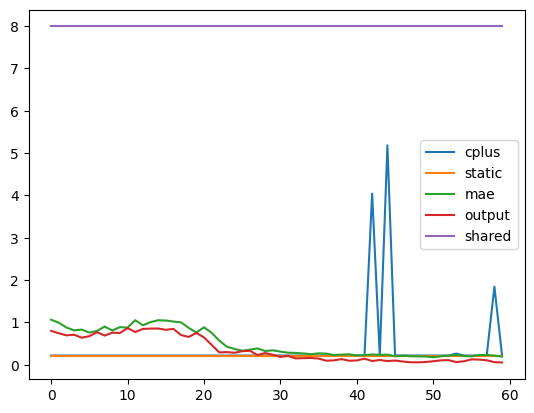

In [27]:
service_idx = 0
plt.plot(static_norm[:,service_idx]+cplus[service_idx,:], label ='cplus')
plt.plot(static_norm[:,service_idx],label = 'static')
plt.plot(helper_norm_mt[:,service_idx],label = 'mae')
plt.plot(output_norm[:,service_idx],label = 'output')
plt.plot(shared_norm,label = 'shared')
plt.legend()

In [ ]:
total_shared = 

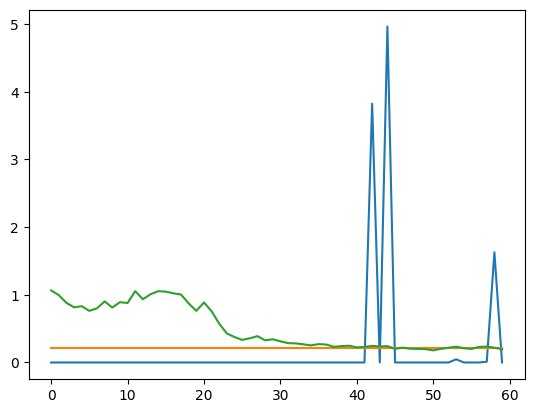

In [28]:
plt.plot(cplus[0,:], label ='cplus')
plt.plot(static_norm[:,0],label = 'static')
plt.plot(helper_norm_mt[:,0],label = 'mae')

In [19]:
static_norm.shape,shared_norm.shape,mae_norm.shape,output_norm.shape

((100, 5), (100, 1), (100, 5, 100), (100, 5))

In [20]:
helper_norm_mt = montecarlo_stuff (mae_norm, 0.999)

In [39]:
shared_norm[1340,0]

7.589430999419799

In [41]:
static_norm[1340,0]

0.8198125546470757

In [40]:
helper_norm_mt[1340,0]

0.7471734209676739